In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:

df = pd.read_csv("pns2019.csv")
df = df[df['C008'] > 60] # selecionar apenas os registros maiores que 60 anos
print(df.shape)

(40676, 1087)


In [ ]:
cols = ["Q00201","Q03001","Q060","Q06306","Q068",
        "Q074","Q079","Q088","Q092","Q11006","Q11604","Q120",'Q124',"Q128"] # colunas de doenças cronicas

df_bem = df[df[cols].eq(2).all(axis=1)] # filtrar apenas pessoas sem doença
print(f'Linhas e Colunas de Pessoas Bem {df_bem.shape}')
df_atri_reu = df[df['Q079'] == 1] # filtrar apenas pessoa com artrite
print(f'Linhas e Colunas de Pessoas com artrite e reumatismo {df_atri_reu.shape}')



Linhas e Colunas de Pessoas Bem (3964, 1087)
Linhas e Colunas de Pessoas com artrite e reumatismo (3835, 1087)


In [38]:
# Remove a coluna 'Q079' da lista de colunas de doenças crônicas, pois será usada para filtrar artrite/reumatismo
cols.remove("Q079")
# Filtra pessoas que não possuem nenhuma das doenças crônicas (exceto artrite/reumatismo)
df_atri_reu_puro = df[ (df[cols].eq(2).all(axis=1))] 
# Seleciona apenas as pessoas que possuem artrite/reumatismo puro (sem outras doenças crônicas)
df_atri_reu_puro = df_atri_reu_puro[df_atri_reu_puro["Q079"] == 1]
# Exibe a quantidade de linhas e colunas do DataFrame resultante
print(f'Linhas e Colunas de Pessoas com  artrite e reumatismo pura {df_atri_reu_puro.shape}')

Linhas e Colunas de Pessoas com  artrite e reumatismo pura (437, 1087)


In [39]:

df_bem

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
60,11,1110011,110000034,8,1,2019,1.0,1,1,1.0,...,NaN,NaN,6298.0,6298.0,7.0,NaN,NaN,NaN,NaN,20210825
89,11,1110011,110000153,6,1,2019,3.0,1,1,1.0,...,NaN,NaN,2696.0,899.0,3.0,NaN,NaN,NaN,NaN,20210825
94,11,1110011,110000153,8,1,2019,2.0,1,1,1.0,...,1.0,5.0,3000.0,1500.0,4.0,NaN,NaN,NaN,NaN,20210825
156,11,1110011,110000584,7,1,2019,3.0,1,1,1.0,...,NaN,NaN,25340.0,8447.0,7.0,NaN,NaN,NaN,NaN,20210825
200,11,1110011,110001520,4,1,2019,4.0,1,1,1.0,...,1.0,1.0,10500.0,2625.0,5.0,NaN,1.0,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293390,53,5310220,530017803,14,1,2019,3.0,2,1,1.0,...,NaN,NaN,2994.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825
293417,53,5310220,530023953,9,1,2019,4.0,2,1,1.0,...,NaN,NaN,1900.0,475.0,2.0,NaN,NaN,NaN,NaN,20210825
293420,53,5310220,530023953,10,1,2019,1.0,2,1,1.0,...,NaN,NaN,920.0,920.0,3.0,NaN,NaN,NaN,NaN,20210825
293497,53,5310220,530028975,7,1,2019,1.0,2,1,1.0,...,1.0,1.0,1098.0,1098.0,4.0,NaN,1.0,1.0,NaN,20210825


In [40]:
df_atri_reu

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
248,11,1110011,110002149,8,1,2019,6.0,1,1,1.0,...,NaN,NaN,4998.0,833.0,3.0,NaN,NaN,NaN,NaN,20210825
607,11,1110011,110005705,4,1,2019,2.0,1,1,1.0,...,NaN,NaN,2000.0,1000.0,4.0,NaN,NaN,NaN,NaN,20210825
668,11,1110011,110005834,9,1,2019,2.0,1,1,1.0,...,1.0,4.0,14800.0,7400.0,7.0,NaN,NaN,NaN,NaN,20210825
717,11,1110011,110007557,12,1,2019,1.0,1,1,1.0,...,NaN,NaN,4480.0,4480.0,6.0,NaN,NaN,NaN,NaN,20210825
1117,11,1110011,110010545,7,1,2019,2.0,1,1,1.0,...,1.0,2.0,2043.0,1022.0,4.0,NaN,NaN,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293109,53,5310213,530025127,6,1,2019,1.0,1,1,1.0,...,NaN,NaN,3000.0,3000.0,6.0,NaN,NaN,NaN,NaN,20210825
293181,53,5310213,530031739,7,1,2019,2.0,1,1,1.0,...,NaN,NaN,5400.0,2700.0,5.0,NaN,NaN,NaN,NaN,20210825
293196,53,5310213,530031739,12,1,2019,2.0,1,1,1.0,...,NaN,NaN,998.0,499.0,2.0,NaN,NaN,NaN,NaN,20210825
293376,53,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825


In [41]:
df_atri_reu_puro

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
2302,11,1110012,110001098,6,1,2019,4.0,1,1,1.0,...,1.0,8.0,3991.0,998.0,3.0,NaN,3.0,NaN,NaN,20210825
5453,11,1152011,110013335,6,1,2019,2.0,1,4,1.0,...,NaN,NaN,2796.0,1398.0,4.0,NaN,NaN,NaN,NaN,20210825
6010,11,1152013,110001240,6,1,2019,1.0,1,4,1.0,...,NaN,NaN,1900.0,1900.0,4.0,NaN,NaN,NaN,NaN,20210825
6577,11,1152021,110009642,13,1,2019,3.0,2,4,1.0,...,NaN,NaN,1996.0,665.0,3.0,NaN,NaN,NaN,NaN,20210825
9129,12,1210010,120005272,10,1,2019,1.0,1,1,1.0,...,NaN,NaN,998.0,998.0,3.0,NaN,NaN,NaN,NaN,20210825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286105,52,5253022,520085026,10,1,2019,3.0,2,4,1.0,...,NaN,NaN,5794.0,1931.0,4.0,NaN,NaN,NaN,NaN,20210825
286286,53,5310111,530003995,13,1,2019,3.0,1,1,1.0,...,NaN,NaN,3498.0,1166.0,4.0,NaN,NaN,NaN,NaN,20210825
287554,53,5310111,530043766,7,1,2019,1.0,1,1,1.0,...,NaN,NaN,12000.0,12000.0,7.0,NaN,NaN,NaN,NaN,20210825
293376,53,5310220,530017803,5,1,2019,2.0,2,1,1.0,...,NaN,NaN,1998.0,999.0,4.0,NaN,NaN,NaN,NaN,20210825


In [42]:
df_uniao = pd.concat([df_bem, df_atri_reu])

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

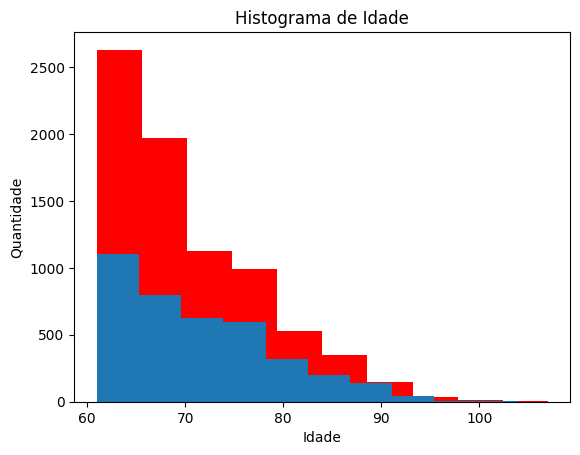

In [43]:
# Plota o histograma da idade das pessoas do DataFrame df_uniao em vermelho
plt.hist(df_uniao['C008'], color='red')
# Plota o histograma da idade das pessoas com artrite/reumatismo
plt.hist(df_atri_reu['C008'])
# Adiciona o título ao gráfico
plt.title('Histograma de Idade')
# Adiciona o rótulo do eixo X
plt.xlabel('Idade')
# Adiciona o rótulo do eixo Y
plt.ylabel('Quantidade')
# (Esta linha não executa nada, deveria ser plt.show() para exibir o gráfico)
plt.plot

In [44]:
import pandas as pd
import numpy as np

def ler_dicionario_sas(path):
    import re
    dicionario = []
    padrao = re.compile(r"@(\d+)\s+(\w+)\s+\$?(\d+)\.\s*/\*([^\*]*)\*/")
    try:
        with open(path, encoding='utf-8') as f:
            for linha in f:
                match = padrao.search(linha)
                if match:
                    posicao = int(match.group(1))
                    nome = match.group(2)
                    tipo = 'str' if '$' in linha else 'num'
                    tamanho = int(match.group(3))
                    descricao = match.group(4).strip()
                    dicionario.append({
                        'posicao': posicao,
                        'nome': nome,
                        'tipo': tipo,
                        'tamanho': tamanho,
                        'descricao': descricao
                    })
    except UnicodeDecodeError:
        with open(path, encoding='latin1') as f:
            for linha in f:
                match = padrao.search(linha)
                if match:
                    posicao = int(match.group(1))
                    nome = match.group(2)
                    tipo = 'str' if '$' in linha else 'num'
                    tamanho = int(match.group(3))
                    descricao = match.group(4).strip()
                    dicionario.append({
                        'posicao': posicao,
                        'nome': nome,
                        'tipo': tipo,
                        'tamanho': tamanho,
                        'descricao': descricao
                    })
    return dicionario

def analisar_nulos_por_modulo(df, nome_dataframe, dicionario=None):
    print(f"--- Análise de Dados Faltantes: {nome_dataframe} ---")
    print(f"Total de registros: {df.shape[0]} | Total de colunas: {df.shape[1]}\n")
    
    nulos_por_coluna = df.isnull().sum()
    df_nulos = pd.DataFrame({'Coluna': nulos_por_coluna.index, 'Qtd_Nulos': nulos_por_coluna.values})
    
    df_nulos['Modulo'] = df_nulos['Coluna'].str.extract(r'^([a-zA-Z])', expand=False).str.upper()
    
    # Organiza por módulo e por coluna dentro de cada módulo
    df_nulos_sorted = df_nulos.sort_values(by=['Modulo', 'Coluna'])
    print("Nulos por coluna (quantidade), organizado por módulo:")
    for modulo, grupo in df_nulos_sorted.groupby('Modulo'):
        print(f"\nMódulo {modulo}:")
        print(grupo[['Coluna', 'Qtd_Nulos']].to_string(index=False))
    print("\n" + "="*50 + "\n")
    
    resumo_modulo = df_nulos.groupby('Modulo')['Qtd_Nulos'].agg(['mean', 'sum', 'count']).reset_index()
    resumo_modulo.columns = ['Módulo', 'Média de Nulos', 'Total de Nulos', 'Qtd de Colunas no Módulo']
    
    print("Resumo por módulo:")
    print(resumo_modulo.sort_values(by='Módulo').to_string(index=False))
    print("\n" + "="*50 + "\n")
    
    if dicionario is not None:
        print("Dicionário de variáveis:")
        print(pd.DataFrame(dicionario))
        print("\n" + "="*50 + "\n")

dicionario_pns = ler_dicionario_sas('input_PNS_2019.txt')
analisar_nulos_por_modulo(df_bem, "Pessoas Bem", dicionario_pns)
analisar_nulos_por_modulo(df_atri_reu, "Pessoas com Artrite", dicionario_pns)
analisar_nulos_por_modulo(df_atri_reu_puro, "Artrite Pura", dicionario_pns)

--- Análise de Dados Faltantes: Pessoas Bem ---
Total de registros: 3964 | Total de colunas: 1087

Nulos por coluna (quantidade), organizado por módulo:

Módulo A:
 Coluna  Qtd_Nulos
   A001          0
A002010          0
A003010          0
A004010          0
A005010          0
A005012       2912
 A00601          0
A009010          0
 A01001          0
   A011          0
 A01401          0
 A01402       3760
 A01403       3778
 A01501         60
A016010          0
A018011          0
A018012        258
A018013          0
A018014        110
A018015          0
A018016       1756
A018017          0
A018018       2828
A018019          0
A018020        729
A018021          0
A018022       2370
A018023          0
A018024       2954
A018025          0
A018026       3322
A018027          0
A018028       2410
 A01901          0
 A02101          0
 A02102       3688
 A02201          0
 A02305       1806
 A02306       1806
 A02307       1806
 A02308       1806
 A02401       3038
 A02402       2245
